In [1]:
import torch
from tqdm import tqdm

In [1]:
!pip install h5py
!pip install monai
!pip install --upgrade ipywidgets
!pip install tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 34.5 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 23.3 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 914.9/914.9 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 44.4 MB/s eta 0:00:00
  Attempting uninstall: widgetsnbextension
    Found existing installation: widgetsnbextension 4.0.13
    Uninstalling widgetsnbextension-4.0.13:
      Successfully uninstalled widgetsnbextension-4.0.13
  Attempting uninstall: jupyterlab_widgets
    Found existing installation: jupyterlab_widgets 3.0.13
    Uninstalling jupyterlab_widgets-3.0.13:
      Successfully uninstalled jupyterlab_widgets-3.0.13
  Attempting uninstall: ipywidg

In [1]:
import h5py
import torch
from torch.utils.data import Dataset, DataLoader
from monai.transforms import Compose, ScaleIntensity

class CTVolumeDataset(Dataset):
    def __init__(self, hdf_path, group_names=["Vol_full"], volume=False, n_slices=None, transform=None):
        self.hdf_path = hdf_path
        self.group_names = group_names
        self.volume = volume
        self.n_slices = n_slices
        self.transform = transform
        self.index_map = []

        with h5py.File(self.hdf_path, "r") as f:
            for group_name in group_names:
                if group_name not in f:
                    raise ValueError(f"Group '{group_name}' not found in HDF5 file.")
                for key in f[group_name].keys():
                    vol = f[group_name][key][()]
                    if volume:
                        if n_slices is not None and vol.ndim == 3 and n_slices < vol.shape[0]:
                            step = vol.shape[0] / n_slices
                            indices = [int(step * i + step / 2) for i in range(n_slices)]
                            self.index_map.append((group_name, key, indices))
                        else:
                            self.index_map.append((group_name, key, None))
                    else:
                        total_slices = vol.shape[0] if vol.ndim == 3 else vol.shape[1]
                        slice_indices = range(total_slices)
                        if n_slices is not None:
                            step = max(1, total_slices // n_slices)
                            slice_indices = slice_indices[::step][:n_slices]
                        for s in slice_indices:
                            self.index_map.append((group_name, key, s))

    def __len__(self):
        return len(self.index_map)

    def __getitem__(self, idx):
        group_name, key, slice_idx = self.index_map[idx]
        with h5py.File(self.hdf_path, "r") as f:
            vol = f[group_name][key][()]

        if self.volume:
            if slice_idx is not None:
                vol = vol[slice_idx]
            if vol.ndim == 3:
                vol = vol[None, ...]
        else:
            if vol.ndim == 3:
                vol = vol[slice_idx]
            elif vol.ndim == 4:
                vol = vol[0, slice_idx]
            vol = vol[None, ...]

        vol = torch.from_numpy(vol).float()
        if self.transform:
            vol = self.transform(vol)
        return vol

In [2]:
hdf_path = "/workspace/ct_rate_train_batch_0_v13.hdf"

In [5]:
dataset = CTVolumeDataset(hdf_path, volume=False)
loader = DataLoader(dataset, batch_size=2, shuffle=False)

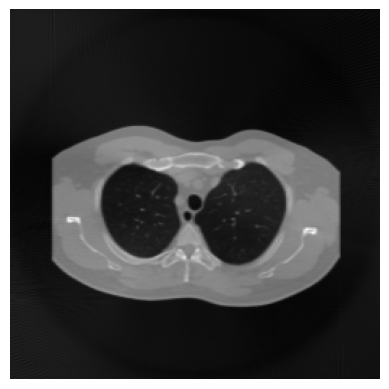

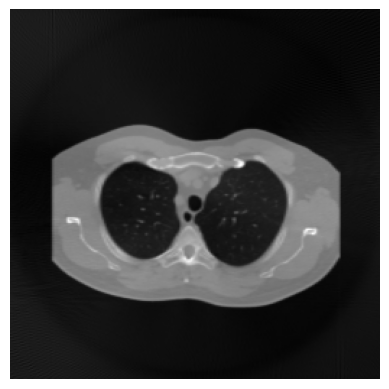

In [7]:
import matplotlib.pyplot as plt
batch = next(iter(loader))
for i in range(batch.shape[0]):
    slice_img = batch[i, 0].numpy()  # remove channel dimension
    plt.figure()
    plt.imshow(slice_img, cmap="gray")
    plt.axis("off")
    plt.show()

In [8]:
batch.shape


torch.Size([2, 1, 256, 256])

In [13]:
pipeline_2d = Compose([ScaleIntensity(minv=0.0, maxv=1.0)])
pipeline_3d = Compose([ScaleIntensity(minv=0.0, maxv=1.0)])

dataset_2d = CTVolumeDataset(hdf_path, group_names=["Vol_full"], volume=False, n_slices=16, transform=pipeline_2d)
dataset_3d = CTVolumeDataset(hdf_path, group_names=["Vol_full"], volume=True, n_slices=64, transform=pipeline_3d)

loader_2d = DataLoader(dataset_2d, batch_size=2, shuffle=False)
loader_3d = DataLoader(dataset_3d, batch_size=2, shuffle=False)

batch_2d = next(iter(loader_2d))
batch_3d = next(iter(loader_3d))

print("2D batch shape:", batch_2d.shape)
print("3D batch shape:", batch_3d.shape)

2D batch shape: torch.Size([2, 1, 256, 256])
3D batch shape: torch.Size([2, 1, 64, 256, 256])


In [5]:
from monai.metrics import PSNRMetric
from monai.metrics.utils import MetricReduction

batch = next(iter(loader_2d))

max_val = float(batch.max() - batch.min())
psnr_metric = PSNRMetric(max_val=max_val, reduction=MetricReduction.MEAN)

slice1 = batch[0]
slice2 = batch[1]

psnr_metric(slice1, slice2)

psnr_value = psnr_metric.aggregate()
print("PSNR between Slice 1 and Slice 2:", psnr_value.item())

PSNR between Slice 1 and Slice 2: 22.20220184326172


In [9]:
from dc_gen.ae_model_zoo import DCAE_HF

In [10]:
model_name = "dc-ae-f32c32-in-1.0"

In [3]:
import os
import torch
from tqdm import tqdm
from monai.metrics import PSNRMetric
from monai.metrics.utils import MetricReduction
import matplotlib.pyplot as plt

# create artifacts folder
artifact_dir = "artifacts_2"
os.makedirs(artifact_dir, exist_ok=True)

device = torch.device("cuda")

model = DCAE_HF(model_name=model_name).to(dtype=torch.bfloat16, device=device)
model.train()

lr = 1e-5
batch_size = loader_2d.batch_size if hasattr(loader_2d, 'batch_size') else 1

optimizer = torch.optim.Adam(model.parameters(), lr=lr)

batch_2d = next(iter(loader_2d))

if batch_2d.ndim == 3:
    batch_2d = batch_2d.unsqueeze(1)

batch_2d = batch_2d.to(dtype=torch.bfloat16, device=device)

max_val = float(batch_2d.max() - batch_2d.min())
psnr_metric = PSNRMetric(max_val=max_val, reduction=MetricReduction.MEAN)

loss_history = []
psnr_history = []

# log file
log_file = os.path.join(artifact_dir, "training_log.txt")
with open(log_file, "w") as f:
    pbar = tqdm(range(8000))
    for it in pbar:
        latent = model.encoder(batch_2d)
        recon = model.decoder(latent)

        loss = torch.nn.functional.l1_loss(recon, batch_2d)
        loss_history.append(loss.item())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        psnr_metric(recon, batch_2d)
        psnr_value = psnr_metric.aggregate().item()
        psnr_history.append(psnr_value)

        pbar.set_postfix({'loss': loss.item(), 'PSNR': psnr_value})
        
        # write log
        f.write(f"iter {it}: loss={loss.item():.6f}, PSNR={psnr_value:.6f}\n")

# Plot loss and PSNR curves
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(loss_history, 'r-', label='Loss')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Loss', color='r')
ax1.tick_params(axis='y', labelcolor='r')

ax2 = ax1.twinx()
ax2.plot(psnr_history, 'b-', label='PSNR')
ax2.set_ylabel('PSNR', color='b')
ax2.tick_params(axis='y', labelcolor='b')

fig.tight_layout()
plt.title(f'Training Curves (lr={lr}, batch_size={batch_size})')

# Save figure
curve_path = os.path.join(artifact_dir, f'training_curves_lr{lr}_bs{batch_size}.png')
plt.savefig(curve_path, dpi=300)
plt.close()

# Optionally save a reconstruction image
recon_img = recon[0, 0].detach().cpu().float().numpy()
gt_img = batch_2d[0, 0].detach().cpu().float().numpy()
diff_img = (gt_img - recon_img).abs()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(gt_img, cmap='gray'); axes[0].axis('off'); axes[0].set_title("Ground Truth")
axes[1].imshow(recon_img, cmap='gray'); axes[1].axis('off'); axes[1].set_title("Reconstruction")
axes[2].imshow(diff_img, cmap='hot'); axes[2].axis('off'); axes[2].set_title("Difference")

plt.tight_layout()
recon_path = os.path.join(artifact_dir, "reconstruction.png")
plt.savefig(recon_path, dpi=300)
plt.close()

CFG.dims 3
Building downsample block with block_type ConvPixelUnshuffle in_channels 1 out_channels 256 shortcut None dims 3
Number of out channels 256
Building downsample block with block_type ConvPixelUnshuffle in_channels 256 out_channels 512 shortcut averaging dims 3
Building downsample block with block_type ConvPixelUnshuffle in_channels 512 out_channels 512 shortcut averaging dims 3
Building downsample block with block_type ConvPixelUnshuffle in_channels 512 out_channels 1024 shortcut averaging dims 3
Building downsample block with block_type ConvPixelUnshuffle in_channels 1024 out_channels 1024 shortcut averaging dims 3


NameError: name 'loader_2d' is not defined

In [14]:
import os
import torch
from tqdm import tqdm
from monai.metrics import PSNRMetric
from monai.metrics.utils import MetricReduction
import matplotlib.pyplot as plt

artifact_dir = "artifacts_3"
os.makedirs(artifact_dir, exist_ok=True)

device = torch.device("cuda")

model = DCAE_HF(model_name=model_name).to(dtype=torch.bfloat16, device=device)
model.train()

lr = 1e-5
batch_size = loader_3d.batch_size if hasattr(loader_3d, 'batch_size') else 1

optimizer = torch.optim.Adam(model.parameters(), lr=lr)

batch_3d = next(iter(loader_3d))

if batch_3d.ndim == 4:  # [B, D, H, W] -> add channel
    batch_3d = batch_3d.unsqueeze(1)

batch_3d = batch_3d.to(dtype=torch.bfloat16, device=device)

max_val = float(batch_3d.max() - batch_3d.min())
psnr_metric = PSNRMetric(max_val=max_val, reduction=MetricReduction.MEAN)

loss_history = []
psnr_history = []

log_file = os.path.join(artifact_dir, "training_log.txt")
with open(log_file, "w") as f:
    pbar = tqdm(range(8000))
    for it in pbar:
        latent = model.encoder(batch_3d)
        recon = model.decoder(latent)

        loss = torch.nn.functional.l1_loss(recon, batch_3d)
        loss_history.append(loss.item())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        psnr_metric(recon, batch_3d)
        psnr_value = psnr_metric.aggregate().item()
        psnr_history.append(psnr_value)

        pbar.set_postfix({'loss': loss.item(), 'PSNR': psnr_value})
        f.write(f"iter {it}: loss={loss.item():.6f}, PSNR={psnr_value:.6f}\n")

# Plot loss and PSNR curves
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(loss_history, 'r-', label='Loss')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Loss', color='r')
ax1.tick_params(axis='y', labelcolor='r')

ax2 = ax1.twinx()
ax2.plot(psnr_history, 'b-', label='PSNR')
ax2.set_ylabel('PSNR', color='b')
ax2.tick_params(axis='y', labelcolor='b')

fig.tight_layout()
plt.title(f'Training Curves (lr={lr}, batch_size={batch_size})')

curve_path = os.path.join(artifact_dir, f'training_curves_lr{lr}_bs{batch_size}.png')
plt.savefig(curve_path, dpi=300)
plt.close()

# Visualize central slice of the first sample
depth_center = batch_3d.shape[2] // 2
recon_img = recon[0, 0, depth_center].detach().cpu().float().numpy()
gt_img = batch_3d[0, 0, depth_center].detach().cpu().float().numpy()
diff_img = (gt_img - recon_img).abs()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(gt_img, cmap='gray'); axes[0].axis('off'); axes[0].set_title("Ground Truth")
axes[1].imshow(recon_img, cmap='gray'); axes[1].axis('off'); axes[1].set_title("Reconstruction")
axes[2].imshow(diff_img, cmap='hot'); axes[2].axis('off'); axes[2].set_title("Difference")

plt.tight_layout()
recon_path = os.path.join(artifact_dir, "reconstruction_central_slice.png")
plt.savefig(recon_path, dpi=300)
plt.close()

CFG.dims 3
Building downsample block with block_type ConvPixelUnshuffle in_channels 1 out_channels 256 shortcut None dims 3
Number of out channels 256
Building downsample block with block_type ConvPixelUnshuffle in_channels 256 out_channels 512 shortcut averaging dims 3
Building downsample block with block_type ConvPixelUnshuffle in_channels 512 out_channels 512 shortcut averaging dims 3
Building downsample block with block_type ConvPixelUnshuffle in_channels 512 out_channels 1024 shortcut averaging dims 3
Building downsample block with block_type ConvPixelUnshuffle in_channels 1024 out_channels 1024 shortcut averaging dims 3


  0%|          | 0/8000 [00:00<?, ?it/s]

After project_in torch.Size([2, 256, 32, 128, 128])


  0%|          | 0/8000 [00:00<?, ?it/s]

After main stages torch.Size([2, 1024, 2, 8, 8])


AttributeError: 'Encoder' object has no attribute 'project_out'

In [4]:
import torch
from dc_gen.ae_model_zoo import DCAE_HF

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_name = "dc-ae-f32c32-in-1.0"
model = DCAE_HF(model_name=model_name).to(dtype=torch.bfloat16, device=device)
model.eval()

# Fake 3D volume: [B, D, H, W]
B, D, H, W = 1, 16, 64, 64
volume = torch.randn(B, D, H, W, dtype=torch.bfloat16, device=device)

# Add channel dimension if needed: [B, C=1, D, H, W]
if volume.ndim == 4:
    volume = volume.unsqueeze(1)

# Forward pass through encoder and decoder
with torch.no_grad():
    latent = model.encoder(volume)
    #recon = model.decoder(latent)

print(f"Input shape: {volume.shape}")
print(f"Latent shape: {latent.shape if isinstance(latent, torch.Tensor) else [l.shape for l in latent]}")
print(f"Reconstruction shape: {recon.shape}")

CFG.dims 3
Building downsample block with block_type ConvPixelUnshuffle in_channels 1 out_channels 256 shortcut None dims 3
Number of out channels 256
Building downsample block with block_type ConvPixelUnshuffle in_channels 256 out_channels 512 shortcut averaging dims 3
Building downsample block with block_type ConvPixelUnshuffle in_channels 512 out_channels 512 shortcut averaging dims 3
Building downsample block with block_type ConvPixelUnshuffle in_channels 512 out_channels 1024 shortcut averaging dims 3
Building downsample block with block_type ConvPixelUnshuffle in_channels 1024 out_channels 1024 shortcut averaging dims 3
After project_in torch.Size([1, 256, 8, 32, 32])


AssertionError: All spatial dims must be divisible by factor

In [7]:
recon.shape

NameError: name 'recon' is not defined

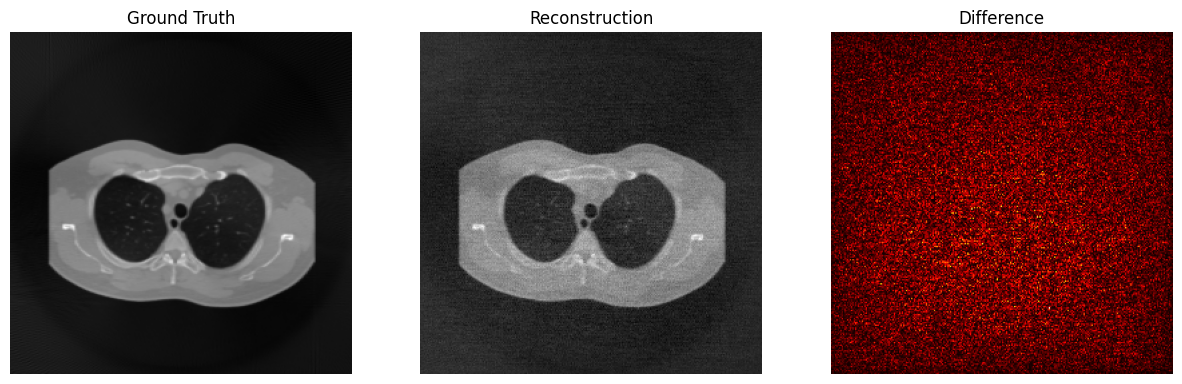

In [31]:
import matplotlib.pyplot as plt
import torch

# pick first image in batch, first channel
gt_img = batch_2d[0, 0]        # ground truth
recon_img = recon[0, 0]        # reconstructed

# convert to NumPy
gt_np = gt_img.detach().cpu().float().numpy()
recon_np = recon_img.detach().cpu().float().numpy()
diff_np = (gt_img - recon_img).abs().detach().cpu().float().numpy()  # absolute difference

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(gt_np, cmap='gray')
axes[0].set_title("Ground Truth")
axes[0].axis('off')

axes[1].imshow(recon_np, cmap='gray')
axes[1].set_title("Reconstruction")
axes[1].axis('off')

axes[2].imshow(diff_np, cmap='hot')
axes[2].set_title("Difference")
axes[2].axis('off')

plt.show()

In [15]:
num_params = sum(p.numel() for p in model.parameters())
size_bytes = sum(p.numel() * p.element_size() for p in model.parameters())
size_gb = size_bytes / 1024**3

print(f"{num_params:,} parameters")
print(f"{num_params/1e6:.2f}M parameters")
print(f"{size_gb:.2f} GB")

341,278,884 parameters
341.28M parameters
0.64 GB


In [11]:
batch_2d.shape

torch.Size([2, 1, 256, 256])